In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
from pathlib import Path

project_path = Path(r"C:\Users\RENUKA\Documents\Task\Notes\Indigo\Flight_Delay_Prediction")

print("Project files:\n")

for file in project_path.iterdir():
    print(file)

Project files:

C:\Users\RENUKA\Documents\Task\Notes\Indigo\Flight_Delay_Prediction\.git
C:\Users\RENUKA\Documents\Task\Notes\Indigo\Flight_Delay_Prediction\.gitignore
C:\Users\RENUKA\Documents\Task\Notes\Indigo\Flight_Delay_Prediction\.ipynb_checkpoints
C:\Users\RENUKA\Documents\Task\Notes\Indigo\Flight_Delay_Prediction\Data
C:\Users\RENUKA\Documents\Task\Notes\Indigo\Flight_Delay_Prediction\models
C:\Users\RENUKA\Documents\Task\Notes\Indigo\Flight_Delay_Prediction\Notebooks
C:\Users\RENUKA\Documents\Task\Notes\Indigo\Flight_Delay_Prediction\outputs
C:\Users\RENUKA\Documents\Task\Notes\Indigo\Flight_Delay_Prediction\scripts


In [3]:
from pathlib import Path

data_path = project_path / "Data"

print("Data files:\n")

for file in data_path.iterdir():
    print(file.name)

Data files:

airlines.csv
airports.csv
flights.csv


In [4]:
# Load datasets

flights = pd.read_csv(data_path / "flights.csv")
airlines = pd.read_csv(data_path / "airlines.csv")
airports = pd.read_csv(data_path / "airports.csv")

print("Flights shape:", flights.shape)
print("Airlines shape:", airlines.shape)
print("Airports shape:", airports.shape)

C:\Users\RENUKA\AppData\Local\Temp\ipykernel_15804\1876580672.py:3: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  flights = pd.read_csv(data_path / "flights.csv")


Flights shape: (5819079, 31)
Airlines shape: (14, 2)
Airports shape: (322, 7)


In [5]:
print("=== FLIGHTS DATA AUDIT ===")

print("\nShape:")
print(flights.shape)

print("\nColumns:")
print(flights.columns.tolist())

print("\nData types:")
print(flights.dtypes)

print("\nMissing values:")
print(flights.isnull().sum())

print("\nDuplicate rows:")
print(flights.duplicated().sum())

=== FLIGHTS DATA AUDIT ===

Shape:
(5819079, 31)

Columns:
['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER', 'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME', 'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON', 'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']

Data types:
YEAR                     int64
MONTH                    int64
DAY                      int64
DAY_OF_WEEK              int64
AIRLINE                 object
FLIGHT_NUMBER            int64
TAIL_NUMBER             object
ORIGIN_AIRPORT          object
DESTINATION_AIRPORT     object
SCHEDULED_DEPARTURE      int64
DEPARTURE_TIME         float64
DEPARTURE_DELAY        float64
TAXI_OUT               float64
WHEELS_OFF             float64
SCHED

In [6]:
print("=== UNIQUE VALUES IN MIXED-TYPE COLUMNS ===")

for col in ['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT']:
    print(f"\n{col}:")
    print(flights[col].head(20).tolist())
    print("Number of unique values:", flights[col].nunique())

=== UNIQUE VALUES IN MIXED-TYPE COLUMNS ===

ORIGIN_AIRPORT:
['ANC', 'LAX', 'SFO', 'LAX', 'SEA', 'SFO', 'LAS', 'LAX', 'SFO', 'LAS', 'DEN', 'LAS', 'LAX', 'SLC', 'SEA', 'ANC', 'ANC', 'SFO', 'ANC', 'PDX']
Number of unique values: 930

DESTINATION_AIRPORT:
['SEA', 'PBI', 'CLT', 'MIA', 'ANC', 'MSP', 'MSP', 'CLT', 'DFW', 'ATL', 'ATL', 'MIA', 'MSP', 'ATL', 'MSP', 'SEA', 'SEA', 'IAH', 'PDX', 'MSP']
Number of unique values: 930


In [7]:
print("=== TARGET & OPERATIONAL STATUS ===")

print("\nCancelled flights:")
print(flights['CANCELLED'].value_counts())

print("\nDiverted flights:")
print(flights['DIVERTED'].value_counts())

print("\nDeparture delay statistics:")
print(flights['DEPARTURE_DELAY'].describe())

print("\nArrival delay statistics:")
print(flights['ARRIVAL_DELAY'].describe())

=== TARGET & OPERATIONAL STATUS ===

Cancelled flights:
CANCELLED
0    5729195
1      89884
Name: count, dtype: int64

Diverted flights:
DIVERTED
0    5803892
1      15187
Name: count, dtype: int64

Departure delay statistics:
count    5.732926e+06
mean     9.370158e+00
std      3.708094e+01
min     -8.200000e+01
25%     -5.000000e+00
50%     -2.000000e+00
75%      7.000000e+00
max      1.988000e+03
Name: DEPARTURE_DELAY, dtype: float64

Arrival delay statistics:
count    5.714008e+06
mean     4.407057e+00
std      3.927130e+01
min     -8.700000e+01
25%     -1.300000e+01
50%     -5.000000e+00
75%      8.000000e+00
max      1.971000e+03
Name: ARRIVAL_DELAY, dtype: float64


In [8]:
print("=== DELAY RELATIONSHIP ===")

print("\nFlights with departure delay:")
print(flights['DEPARTURE_DELAY'].notna().sum())

print("\nFlights with arrival delay:")
print(flights['ARRIVAL_DELAY'].notna().sum())

print("\nFlights with departure delay >= 15 minutes:")
print((flights['DEPARTURE_DELAY'] >= 15).sum())

print("\nFlights with arrival delay >= 15 minutes:")
print((flights['ARRIVAL_DELAY'] >= 15).sum())

=== DELAY RELATIONSHIP ===

Flights with departure delay:
5732926

Flights with arrival delay:
5714008

Flights with departure delay >= 15 minutes:
1057554

Flights with arrival delay >= 15 minutes:
1063439


In [9]:
# Create a working copy
df = flights.copy()

# Keep only flights that actually operated
df = df[df['CANCELLED'] == 0].copy()

# Create binary delay target
df['is_delayed'] = (df['DEPARTURE_DELAY'] >= 15).astype(int)

print("=== CLEAN ANALYSIS DATASET ===")

print("Shape:", df.shape)

print("\nCancelled flights remaining:")
print(df['CANCELLED'].sum())

print("\nTarget distribution:")
print(df['is_delayed'].value_counts())

print("\nTarget percentage:")
print(df['is_delayed'].value_counts(normalize=True).mul(100).round(2))

=== CLEAN ANALYSIS DATASET ===
Shape: (5729195, 32)

Cancelled flights remaining:
0

Target distribution:
is_delayed
0    4673695
1    1055500
Name: count, dtype: int64

Target percentage:
is_delayed
0    81.58
1    18.42
Name: proportion, dtype: float64


In [10]:
print("\nMissing departure delay values:")
print(df['DEPARTURE_DELAY'].isna().sum())

print("\nMissing target values:")
print(df['is_delayed'].isna().sum())


Missing departure delay values:
0

Missing target values:
0


## EDA

In [11]:
print("=== BASIC STATISTICS ===")

print("\nNumerical summary:")
display(df.describe().T)

=== BASIC STATISTICS ===

Numerical summary:


,count,mean,std,min,25%,50%,75%,max
YEAR,5729195.0,2015.000000,0.000000,2015.0,2015.0,2015.0,2015.0,2015.0
MONTH,5729195.0,6.547562,3.397027,1.0,4.0,7.0,9.0,12.0
DAY,5729195.0,15.708485,8.774635,1.0,8.0,16.0,23.0,31.0
DAY_OF_WEEK,5729195.0,3.932479,1.986101,1.0,2.0,4.0,6.0,7.0
FLIGHT_NUMBER,5729195.0,2164.752836,1754.923501,1.0,728.0,1681.0,3212.0,9320.0
SCHEDULED_DEPARTURE,5729195.0,1328.890409,483.469220,1.0,916.0,1325.0,1730.0,2359.0
DEPARTURE_TIME,5729195.0,1335.102392,496.390180,1.0,921.0,1330.0,1740.0,2400.0
DEPARTURE_DELAY,5729195.0,9.338837,36.992462,-82.0,-5.0,-2.0,7.0,1988.0
TAXI_OUT,5729195.0,16.071118,8.894483,1.0,11.0,14.0,19.0,225.0
WHEELS_OFF,5729195.0,1357.141916,497.996904,1.0,935.0,1343.0,1754.0,2400.0


In [12]:
print("=== AIRLINE DISTRIBUTION ===")

airline_counts = df['AIRLINE'].value_counts()

display(airline_counts)

=== AIRLINE DISTRIBUTION ===


AIRLINE
WN    1245812
DL     872057
AA     715065
OO     578393
EV     556746
UA     509150
MQ     279607
B6     262772
US     194648
AS     171852
NK     115375
F9      90248
HA      76101
VX      61369
Name: count, dtype: int64

In [13]:
print("=== DELAY RATE BY AIRLINE ===")

airline_delay = (
    df.groupby('AIRLINE')
      .agg(
          total_flights=('is_delayed', 'count'),
          delayed_flights=('is_delayed', 'sum'),
          delay_rate=('is_delayed', 'mean'),
          avg_departure_delay=('DEPARTURE_DELAY', 'mean')
      )
      .sort_values('delay_rate', ascending=False)
)

airline_delay['delay_rate'] = (
    airline_delay['delay_rate'] * 100
).round(2)

airline_delay['avg_departure_delay'] = (
    airline_delay['avg_departure_delay'].round(2)
)

display(airline_delay)

=== DELAY RATE BY AIRLINE ===


,total_flights,delayed_flights,delay_rate,avg_departure_delay
AIRLINE,,,,
NK,115375,31554,27.35,15.91
UA,509150,120336,23.63,14.38
F9,90248,20754,23.00,13.32
B6,262772,57653,21.94,11.50
WN,1245812,265262,21.29,10.57
MQ,279607,55884,19.99,10.01
VX,61369,11019,17.96,9.01
EV,556746,96669,17.36,8.66
AA,715065,123440,17.26,8.86


In [14]:
print("=== DELAY RATE BY MONTH ===")

monthly_delay = (
    df.groupby('MONTH')
      .agg(
          total_flights=('is_delayed', 'count'),
          delayed_flights=('is_delayed', 'sum'),
          delay_rate=('is_delayed', 'mean'),
          avg_departure_delay=('DEPARTURE_DELAY', 'mean')
      )
)

monthly_delay['delay_rate'] = (
    monthly_delay['delay_rate'] * 100
).round(2)

monthly_delay['avg_departure_delay'] = (
    monthly_delay['avg_departure_delay'].round(2)
)

display(monthly_delay)

=== DELAY RATE BY MONTH ===


,total_flights,delayed_flights,delay_rate,avg_departure_delay
MONTH,,,,
1,457986,90825,19.83,9.73
2,408674,90992,22.27,11.81
3,493310,95379,19.33,9.63
4,480631,79734,16.59,7.68
5,491299,89611,18.24,9.42
6,494777,116599,23.57,13.94
7,515912,109730,21.27,11.37
8,505484,96364,19.06,9.91
9,462871,58427,12.62,4.81


## Step 4 — Day & time operational patterns

In [15]:
print("=== DELAY RATE BY DAY OF WEEK ===")

day_delay = (
    df.groupby('DAY_OF_WEEK')
      .agg(
          total_flights=('is_delayed', 'count'),
          delayed_flights=('is_delayed', 'sum'),
          delay_rate=('is_delayed', 'mean'),
          avg_departure_delay=('DEPARTURE_DELAY', 'mean')
      )
)

day_delay['delay_rate'] = (
    day_delay['delay_rate'] * 100
).round(2)

day_delay['avg_departure_delay'] = (
    day_delay['avg_departure_delay'].round(2)
)

display(day_delay)

=== DELAY RATE BY DAY OF WEEK ===


,total_flights,delayed_flights,delay_rate,avg_departure_delay
DAY_OF_WEEK,,,,
1,844470,165165,19.56,10.82
2,829528,149638,18.04,9.14
3,845168,150867,17.85,8.63
4,860230,166288,19.33,9.93
5,853404,161443,18.92,9.40
6,691796,113389,16.39,7.79
7,804599,148710,18.48,9.37


In [16]:
print("=== DELAY RATE BY DEPARTURE HOUR ===")

df['DEPARTURE_HOUR'] = (
    df['SCHEDULED_DEPARTURE'] // 100
)

hour_delay = (
    df.groupby('DEPARTURE_HOUR')
      .agg(
          total_flights=('is_delayed', 'count'),
          delayed_flights=('is_delayed', 'sum'),
          delay_rate=('is_delayed', 'mean'),
          avg_departure_delay=('DEPARTURE_DELAY', 'mean')
      )
)

hour_delay['delay_rate'] = (
    hour_delay['delay_rate'] * 100
).round(2)

hour_delay['avg_departure_delay'] = (
    hour_delay['avg_departure_delay'].round(2)
)

display(hour_delay)

=== DELAY RATE BY DEPARTURE HOUR ===


,total_flights,delayed_flights,delay_rate,avg_departure_delay
DEPARTURE_HOUR,,,,
0,14539,2425,16.68,7.16
1,5105,897,17.57,8.06
2,1386,244,17.60,7.27
3,767,162,21.12,8.92
4,528,128,24.24,10.34
5,115984,6784,5.85,1.88
6,399618,26529,6.64,2.09
7,388704,34333,8.83,3.23
8,375689,41244,10.98,4.67


In [17]:
print("=== PEAK vs NON-PEAK DEPARTURES ===")

df['IS_PEAK_HOUR'] = (
    df['DEPARTURE_HOUR'].isin(
        [7, 8, 9, 10, 11, 17, 18, 19]
    ).astype(int)
)

peak_delay = (
    df.groupby('IS_PEAK_HOUR')
      .agg(
          total_flights=('is_delayed', 'count'),
          delayed_flights=('is_delayed', 'sum'),
          delay_rate=('is_delayed', 'mean'),
          avg_departure_delay=('DEPARTURE_DELAY', 'mean')
      )
)

peak_delay['delay_rate'] = (
    peak_delay['delay_rate'] * 100
).round(2)

peak_delay['avg_departure_delay'] = (
    peak_delay['avg_departure_delay'].round(2)
)

peak_delay.index = ['Non-Peak', 'Peak']

display(peak_delay)

=== PEAK vs NON-PEAK DEPARTURES ===


,total_flights,delayed_flights,delay_rate,avg_departure_delay
Non-Peak,2860623,551084,19.26,9.85
Peak,2868572,504416,17.58,8.83


## Step 5 — Create a useful time feature

In [18]:
df['DEPARTURE_HOUR']

0           0
1           0
2           0
3           0
4           0
           ..
5819074    23
5819075    23
5819076    23
5819077    23
5819078    23
Name: DEPARTURE_HOUR, Length: 5729195, dtype: int64

In [19]:
# Create operational departure time buckets

def classify_departure_period(hour):
    if 5 <= hour < 9:
        return 'Early Morning'
    elif 9 <= hour < 13:
        return 'Morning'
    elif 13 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['DEPARTURE_PERIOD'] = df['DEPARTURE_HOUR'].apply(
    classify_departure_period
)

period_delay = (
    df.groupby('DEPARTURE_PERIOD')
      .agg(
          total_flights=('is_delayed', 'count'),
          delayed_flights=('is_delayed', 'sum'),
          delay_rate=('is_delayed', 'mean'),
          avg_departure_delay=('DEPARTURE_DELAY', 'mean')
      )
)

period_delay['delay_rate'] = (
    period_delay['delay_rate'] * 100
).round(2)

period_delay['avg_departure_delay'] = (
    period_delay['avg_departure_delay'].round(2)
)

display(period_delay)

,total_flights,delayed_flights,delay_rate,avg_departure_delay
DEPARTURE_PERIOD,,,,
Afternoon,1374647,295159,21.47,11.40
Early Morning,1279995,108890,8.51,3.17
Evening,1290848,341339,26.44,14.69
Morning,1418350,220860,15.57,7.30
Night,365355,89252,24.43,12.19


## Step 6 — Airport operational analysis

In [20]:
print("=== ORIGIN AIRPORT PERFORMANCE ===")

airport_delay = (
    df.groupby('ORIGIN_AIRPORT')
      .agg(
          total_flights=('is_delayed', 'count'),
          delayed_flights=('is_delayed', 'sum'),
          delay_rate=('is_delayed', 'mean'),
          avg_departure_delay=('DEPARTURE_DELAY', 'mean')
      )
)

# Focus on airports with at least 10,000 operated flights
airport_delay_filtered = (
    airport_delay[airport_delay['total_flights'] >= 10000]
    .sort_values('delay_rate', ascending=False)
)

airport_delay_filtered['delay_rate'] = (
    airport_delay_filtered['delay_rate'] * 100
).round(2)

airport_delay_filtered['avg_departure_delay'] = (
    airport_delay_filtered['avg_departure_delay']
    .round(2)
)

print("Number of airports meeting the 10,000-flight threshold:",
      len(airport_delay_filtered))

display(airport_delay_filtered.head(15))

=== ORIGIN AIRPORT PERFORMANCE ===
Number of airports meeting the 10,000-flight threshold: 86


,total_flights,delayed_flights,delay_rate,avg_departure_delay
ORIGIN_AIRPORT,,,,
MDW,78927,19657,24.91,12.82
BWI,84546,20834,24.64,13.31
ORD,277336,67553,24.36,14.07
DAL,58849,14030,23.84,12.00
EWR,98662,23502,23.82,13.58
HOU,51268,12171,23.74,12.12
MIA,68558,15993,23.33,12.50
DEN,193932,44343,22.87,11.81
LGA,95074,21463,22.58,13.18


In [21]:
print("=== BEST-PERFORMING ORIGIN AIRPORTS ===")

display(
    airport_delay_filtered
    .sort_values('delay_rate')
    .head(15)
)

=== BEST-PERFORMING ORIGIN AIRPORTS ===


,total_flights,delayed_flights,delay_rate,avg_departure_delay
ORIGIN_AIRPORT,,,,
LIH,10501,864,8.23,0.55
HNL,42998,3868,9.00,2.65
KOA,11074,998,9.01,1.43
13487,10011,999,9.98,3.33
OGG,20501,2365,11.54,3.53
10397,30796,3562,11.57,4.33
ANC,15881,1934,12.18,3.39
SLC,96815,12319,12.72,4.76
14107,12179,1570,12.89,4.62


## Step 7 — Understand the airport reference table

In [22]:
print("=== AIRPORT REFERENCE DATA ===")

print("Shape:", airports.shape)

display(airports.head(10))

print("\nColumns:")
print(airports.columns.tolist())

print("\nData types:")
print(airports.dtypes)

=== AIRPORT REFERENCE DATA ===
Shape: (322, 7)


,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447
5,ACK,Nantucket Memorial Airport,Nantucket,MA,USA,41.25305,-70.06018
6,ACT,Waco Regional Airport,Waco,TX,USA,31.61129,-97.23052
7,ACV,Arcata Airport,Arcata/Eureka,CA,USA,40.97812,-124.10862
8,ACY,Atlantic City International Airport,Atlantic City,NJ,USA,39.45758,-74.57717
9,ADK,Adak Airport,Adak,AK,USA,51.87796,-176.64603



Columns:
['IATA_CODE', 'AIRPORT', 'CITY', 'STATE', 'COUNTRY', 'LATITUDE', 'LONGITUDE']

Data types:
IATA_CODE     object
AIRPORT       object
CITY          object
STATE         object
COUNTRY       object
LATITUDE     float64
LONGITUDE    float64
dtype: object


In [23]:
print("=== AIRPORT IDENTIFIER TYPES ===")

print("Sample flight airport identifiers:")
print(df['ORIGIN_AIRPORT'].sample(20, random_state=42).tolist())

print("\nAirport reference identifiers:")
print(airports['IATA_CODE'].head(20).tolist())

=== AIRPORT IDENTIFIER TYPES ===
Sample flight airport identifiers:
['ABI', 'DTW', 'RDU', 'ORD', 'BTR', 'FLL', 'MSP', 'SFO', 'DEN', 'PHX', 'ROC', 'PHX', 14307, 'SFO', 'SFO', 14747, 'BWI', 'DEN', 'TVC', 'SLC']

Airport reference identifiers:
['ABE', 'ABI', 'ABQ', 'ABR', 'ABY', 'ACK', 'ACT', 'ACV', 'ACY', 'ADK', 'ADQ', 'AEX', 'AGS', 'AKN', 'ALB', 'ALO', 'AMA', 'ANC', 'APN', 'ASE']


In [24]:
print("=== AIRPORT CODE MATCH CHECK ===")

flight_airport_codes = set(df['ORIGIN_AIRPORT'].unique())
reference_airport_codes = set(airports['IATA_CODE'].dropna().unique())

matched = flight_airport_codes.intersection(reference_airport_codes)

print("Unique origin identifiers in flights:", len(flight_airport_codes))
print("Airport codes in reference table:", len(reference_airport_codes))
print("Matched identifiers:", len(matched))
print("Unmatched identifiers:", len(flight_airport_codes - reference_airport_codes))

=== AIRPORT CODE MATCH CHECK ===
Unique origin identifiers in flights: 929
Airport codes in reference table: 322
Matched identifiers: 322
Unmatched identifiers: 607


## Step 8 — Add airport information safely

In [25]:
# Create airport lookup
airport_lookup = airports[
    ['IATA_CODE', 'AIRPORT', 'CITY', 'STATE', 'LATITUDE', 'LONGITUDE']
].copy()

# Rename lookup columns
airport_lookup = airport_lookup.rename(columns={
    'IATA_CODE': 'ORIGIN_AIRPORT',
    'AIRPORT': 'ORIGIN_AIRPORT_NAME',
    'CITY': 'ORIGIN_CITY',
    'STATE': 'ORIGIN_STATE',
    'LATITUDE': 'ORIGIN_LATITUDE',
    'LONGITUDE': 'ORIGIN_LONGITUDE'
})

# Merge airport information
df_enriched = df.merge(
    airport_lookup,
    on='ORIGIN_AIRPORT',
    how='left'
)

print("Original rows:", len(df))
print("Enriched rows:", len(df_enriched))

print("\nAirport information coverage:")
print(
    df_enriched['ORIGIN_AIRPORT_NAME']
    .notna()
    .mean() * 100
)

Original rows: 5729195
Enriched rows: 5729195

Airport information coverage:
91.5570861176832


In [26]:
print("\n=== ENRICHED AIRPORT DATA ===")

display(
    df_enriched[
        [
            'ORIGIN_AIRPORT',
            'ORIGIN_AIRPORT_NAME',
            'ORIGIN_CITY',
            'ORIGIN_STATE'
        ]
    ].head(20)
)


=== ENRICHED AIRPORT DATA ===


,ORIGIN_AIRPORT,ORIGIN_AIRPORT_NAME,ORIGIN_CITY,ORIGIN_STATE
0,ANC,Ted Stevens Anchorage International Airport,Anchorage,AK
1,LAX,Los Angeles International Airport,Los Angeles,CA
2,SFO,San Francisco International Airport,San Francisco,CA
3,LAX,Los Angeles International Airport,Los Angeles,CA
4,SEA,Seattle-Tacoma International Airport,Seattle,WA
5,SFO,San Francisco International Airport,San Francisco,CA
6,LAS,McCarran International Airport,Las Vegas,NV
7,LAX,Los Angeles International Airport,Los Angeles,CA
8,SFO,San Francisco International Airport,San Francisco,CA
9,LAS,McCarran International Airport,Las Vegas,NV


## Step 9 — Route-level operational analysis

In [27]:
print("=== ROUTE PERFORMANCE ===")

route_delay = (
    df.groupby(['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT'])
      .agg(
          total_flights=('is_delayed', 'count'),
          delayed_flights=('is_delayed', 'sum'),
          delay_rate=('is_delayed', 'mean'),
          avg_departure_delay=('DEPARTURE_DELAY', 'mean'),
          avg_distance=('DISTANCE', 'mean')
      )
)

# Keep routes with at least 1,000 operated flights
route_delay_filtered = (
    route_delay[route_delay['total_flights'] >= 1000]
    .sort_values('delay_rate', ascending=False)
)

route_delay_filtered['delay_rate'] = (
    route_delay_filtered['delay_rate'] * 100
).round(2)

route_delay_filtered['avg_departure_delay'] = (
    route_delay_filtered['avg_departure_delay']
    .round(2)
)

route_delay_filtered['avg_distance'] = (
    route_delay_filtered['avg_distance']
    .round(0)
)

print(
    "Routes meeting the 1,000-flight threshold:",
    len(route_delay_filtered)
)

display(route_delay_filtered.head(15))

=== ROUTE PERFORMANCE ===
Routes meeting the 1,000-flight threshold: 1671


total_flights  delayed_flights  \
ORIGIN_AIRPORT DESTINATION_AIRPORT                                   
SJU            EWR                           1178              439   
IAH            LAX                           4393             1611   
               SFO                           3407             1178   
               LGA                           2275              766   
               EWR                           3169             1042   
BWI            ORF                           1124              368   
ORD            EWR                           3761             1227   
               IAH                           4111             1340   
               JFK                           1543              500   
PBI            BOS                           1573              508   
MDW            SEA                           1019              329   
BWI            DAL                           1075              346   
               BDL                           2138              687   
ORD            DEN                           5537             1768   
PBI            HPN                           1019              324   

                                    delay_rate  avg_departure_delay  \
ORIGIN_AIRPORT DESTINATION_AIRPORT                                    
SJU            EWR                       37.27                19.33   
IAH            LAX                       36.67                22.90   
               SFO                       34.58                22.85   
               LGA                       33.67                21.83   
               EWR                       32.88                21.26   
BWI            ORF                       32.74                16.60   
ORD            EWR                       32.62                23.44   
               IAH                       32.60                20.93   
               JFK                       32.40                22.64   
PBI            BOS                       32.29                18.07   
MDW            SEA                       32.29                17.19   
BWI            DAL                       32.19                16.13   
               BDL                       32.13                16.74   
ORD            DEN                       31.93                22.20   
PBI            HPN                       31.80                17.49   

                                    avg_distance  
ORIGIN_AIRPORT DESTINATION_AIRPORT                
SJU            EWR                        1608.0  
IAH            LAX                        1379.0  
               SFO                        1635.0  
               LGA                        1416.0  
               EWR                        1400.0  
BWI            ORF                         159.0  
ORD            EWR                         719.0  
               IAH                         925.0  
               JFK                         740.0  
PBI            BOS                        1197.0  
MDW            SEA                        1733.0  
BWI            DAL                        1209.0  
               BDL                         283.0  
ORD            DEN                         888.0  
PBI            HPN                        1056.0

In [28]:
print("=== BEST-PERFORMING ROUTES ===")

display(
    route_delay_filtered
    .sort_values('delay_rate')
    .head(15)
)

=== BEST-PERFORMING ROUTES ===


,,total_flights,delayed_flights,delay_rate,avg_departure_delay,avg_distance
ORIGIN_AIRPORT,DESTINATION_AIRPORT,,,,,
IDA,SLC,1318,52,3.95,-3.03,188.0
HNL,LIH,5852,296,5.06,-1.48,102.0
SAN,MSP,1068,57,5.34,4.03,1532.0
BIL,SLC,1057,61,5.77,-0.27,387.0
SLC,SGU,1192,69,5.79,-0.86,272.0
BZN,SLC,1057,62,5.87,-1.23,347.0
PDX,MSP,1290,76,5.89,1.92,1426.0
HNL,KOA,6383,381,5.97,-1.11,163.0
LIH,OGG,1319,82,6.22,-1.01,201.0


## Step 9 — Create a proper route identifier

In [29]:
df['ROUTE'] = (
    df['ORIGIN_AIRPORT'].astype(str)
    + '_'
    + df['DESTINATION_AIRPORT'].astype(str)
)

print("Sample routes:")
print(df['ROUTE'].head(10).tolist())

print("\nUnique routes:", df['ROUTE'].nunique())

Sample routes:
['ANC_SEA', 'LAX_PBI', 'SFO_CLT', 'LAX_MIA', 'SEA_ANC', 'SFO_MSP', 'LAS_MSP', 'LAX_CLT', 'SFO_DFW', 'LAS_ATL']

Unique routes: 8603


In [30]:
route_delay = (
    df.groupby('ROUTE')
      .agg(
          total_flights=('is_delayed', 'count'),
          delayed_flights=('is_delayed', 'sum'),
          delay_rate=('is_delayed', 'mean'),
          avg_departure_delay=('DEPARTURE_DELAY', 'mean'),
          avg_distance=('DISTANCE', 'mean')
      )
)

route_delay_filtered = (
    route_delay[route_delay['total_flights'] >= 1000]
    .sort_values('delay_rate', ascending=False)
    .copy()
)

route_delay_filtered['delay_rate'] = (
    route_delay_filtered['delay_rate'] * 100
).round(2)

route_delay_filtered['avg_departure_delay'] = (
    route_delay_filtered['avg_departure_delay'].round(2)
)

route_delay_filtered['avg_distance'] = (
    route_delay_filtered['avg_distance'].round(0)
)

display(route_delay_filtered.head(15))

,total_flights,delayed_flights,delay_rate,avg_departure_delay,avg_distance
ROUTE,,,,,
SJU_EWR,1178,439,37.27,19.33,1608.0
IAH_LAX,4393,1611,36.67,22.90,1379.0
IAH_SFO,3407,1178,34.58,22.85,1635.0
IAH_LGA,2275,766,33.67,21.83,1416.0
IAH_EWR,3169,1042,32.88,21.26,1400.0
BWI_ORF,1124,368,32.74,16.60,159.0
ORD_EWR,3761,1227,32.62,23.44,719.0
ORD_IAH,4111,1340,32.60,20.93,925.0
ORD_JFK,1543,500,32.40,22.64,740.0


## Step 10 — Build the core operational KPI table

In [31]:
print("=== OVERALL OPERATIONAL KPIs ===")

overall_kpis = pd.DataFrame({
    'Metric': [
        'Total operated flights',
        'Delayed flights (>=15 min)',
        'Delay rate',
        'Average departure delay',
        'Median departure delay',
        'Maximum departure delay'
    ],
    'Value': [
        len(df),
        df['is_delayed'].sum(),
        df['is_delayed'].mean() * 100,
        df['DEPARTURE_DELAY'].mean(),
        df['DEPARTURE_DELAY'].median(),
        df['DEPARTURE_DELAY'].max()
    ]
})

overall_kpis['Value'] = overall_kpis['Value'].round(2)

display(overall_kpis)

=== OVERALL OPERATIONAL KPIs ===


,Metric,Value
0,Total operated flights,5729195.00
1,Delayed flights (>=15 min),1055500.00
2,Delay rate,18.42
3,Average departure delay,9.34
4,Median departure delay,-2.00
5,Maximum departure delay,1988.00


In [32]:
monthly_kpi = (
    df.groupby('MONTH')
      .agg(
          total_flights=('is_delayed', 'count'),
          delayed_flights=('is_delayed', 'sum'),
          delay_rate=('is_delayed', 'mean'),
          avg_departure_delay=('DEPARTURE_DELAY', 'mean')
      )
      .reset_index()
)

monthly_kpi['delay_rate'] = (
    monthly_kpi['delay_rate'] * 100
).round(2)

monthly_kpi['avg_departure_delay'] = (
    monthly_kpi['avg_departure_delay']
).round(2)

display(monthly_kpi)

,MONTH,total_flights,delayed_flights,delay_rate,avg_departure_delay
0,1,457986,90825,19.83,9.73
1,2,408674,90992,22.27,11.81
2,3,493310,95379,19.33,9.63
3,4,480631,79734,16.59,7.68
4,5,491299,89611,18.24,9.42
5,6,494777,116599,23.57,13.94
6,7,515912,109730,21.27,11.37
7,8,505484,96364,19.06,9.91
8,9,462871,58427,12.62,4.81
9,10,483711,60295,12.47,4.97


In [33]:
airline_kpi = (
    df.groupby('AIRLINE')
      .agg(
          total_flights=('is_delayed', 'count'),
          delayed_flights=('is_delayed', 'sum'),
          delay_rate=('is_delayed', 'mean'),
          avg_departure_delay=('DEPARTURE_DELAY', 'mean')
      )
      .reset_index()
)

airline_kpi['delay_rate'] = (
    airline_kpi['delay_rate'] * 100
).round(2)

airline_kpi['avg_departure_delay'] = (
    airline_kpi['avg_departure_delay']
).round(2)

display(
    airline_kpi.sort_values(
        'delay_rate',
        ascending=False
    )
)

,AIRLINE,total_flights,delayed_flights,delay_rate,avg_departure_delay
8,NK,115375,31554,27.35,15.91
10,UA,509150,120336,23.63,14.38
5,F9,90248,20754,23.00,13.32
2,B6,262772,57653,21.94,11.50
13,WN,1245812,265262,21.29,10.57
7,MQ,279607,55884,19.99,10.01
12,VX,61369,11019,17.96,9.01
4,EV,556746,96669,17.36,8.66
0,AA,715065,123440,17.26,8.86
9,OO,578393,96304,16.65,7.77


## Step 11 — Create the first visualizations

### 1. Monthly delay trend

In [34]:
month_names = {
    1: 'January',
    2: 'February',
    3: 'March',
    4: 'April',
    5: 'May',
    6: 'June',
    7: 'July',
    8: 'August',
    9: 'September',
    10: 'October',
    11: 'November',
    12: 'December'
}

monthly_plot = monthly_kpi.copy()
monthly_plot['MONTH_NAME'] = monthly_plot['MONTH'].map(month_names)

display(monthly_plot)

,MONTH,total_flights,delayed_flights,delay_rate,avg_departure_delay,MONTH_NAME
0,1,457986,90825,19.83,9.73,January
1,2,408674,90992,22.27,11.81,February
2,3,493310,95379,19.33,9.63,March
3,4,480631,79734,16.59,7.68,April
4,5,491299,89611,18.24,9.42,May
5,6,494777,116599,23.57,13.94,June
6,7,515912,109730,21.27,11.37,July
7,8,505484,96364,19.06,9.91,August
8,9,462871,58427,12.62,4.81,September
9,10,483711,60295,12.47,4.97,October


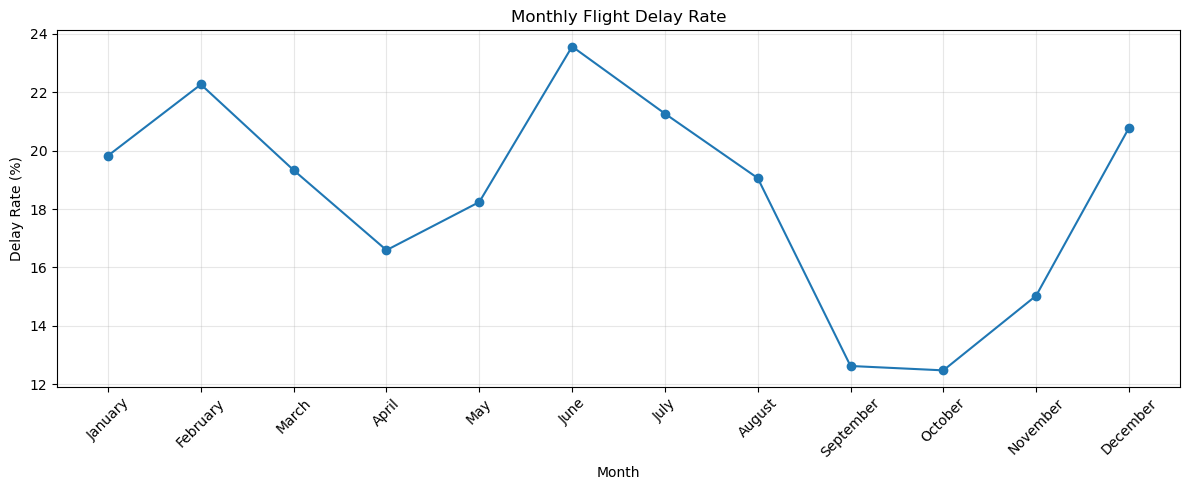

In [35]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_plot['MONTH_NAME'],
    monthly_plot['delay_rate'],
    marker='o'
)

plt.title('Monthly Flight Delay Rate')
plt.xlabel('Month')
plt.ylabel('Delay Rate (%)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 2. Airline delay comparison

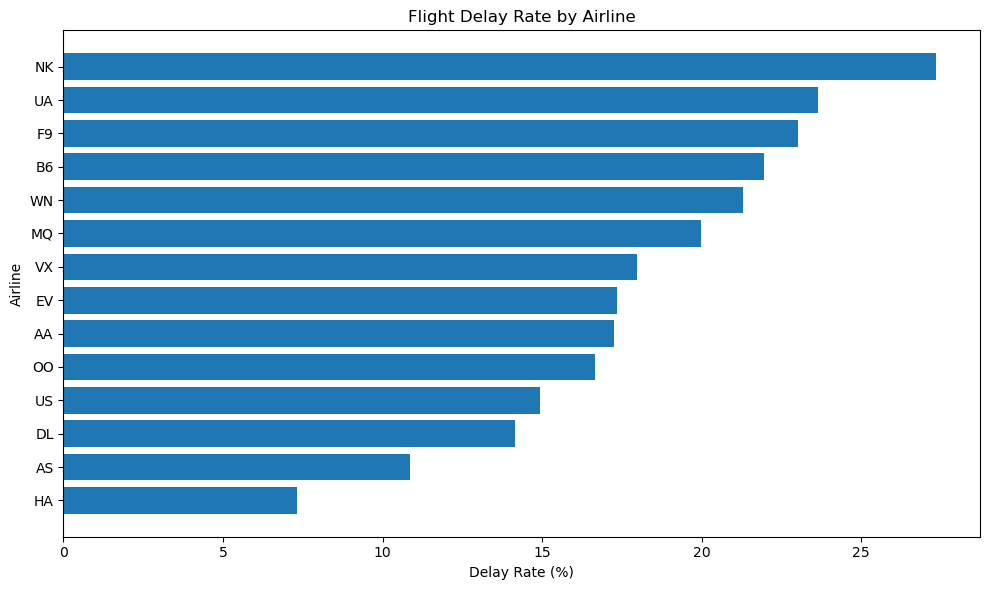

In [36]:
airline_plot = airline_kpi.sort_values(
    'delay_rate',
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    airline_plot['AIRLINE'],
    airline_plot['delay_rate']
)

plt.title('Flight Delay Rate by Airline')
plt.xlabel('Delay Rate (%)')
plt.ylabel('Airline')

plt.tight_layout()
plt.show()

### 3. Departure-hour pattern

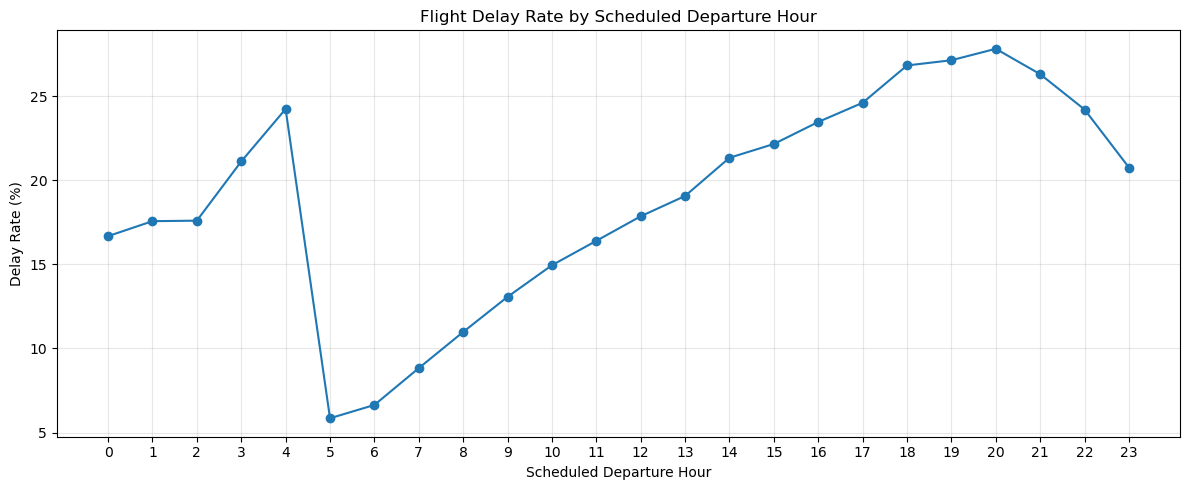

In [37]:
plt.figure(figsize=(12, 5))

plt.plot(
    hour_delay.index,
    hour_delay['delay_rate'],
    marker='o'
)

plt.title('Flight Delay Rate by Scheduled Departure Hour')
plt.xlabel('Scheduled Departure Hour')
plt.ylabel('Delay Rate (%)')
plt.xticks(range(24))
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Step 1 — Create the flight date and chronological train/test split

In [38]:
# Create a proper flight date
df['FLIGHT_DATE'] = pd.to_datetime(
    dict(
        year=df['YEAR'],
        month=df['MONTH'],
        day=df['DAY']
    )
)

# Sort chronologically
df = df.sort_values('FLIGHT_DATE').reset_index(drop=True)

# Use the first 80% of dates for training
unique_dates = df['FLIGHT_DATE'].drop_duplicates().sort_values().reset_index(drop=True)

split_date = unique_dates.iloc[int(len(unique_dates) * 0.80)]

train_df = df[df['FLIGHT_DATE'] < split_date].copy()
test_df = df[df['FLIGHT_DATE'] >= split_date].copy()

print("Split date:", split_date)
print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

print("\nTraining date range:")
print(train_df['FLIGHT_DATE'].min(), "to", train_df['FLIGHT_DATE'].max())

print("\nTesting date range:")
print(test_df['FLIGHT_DATE'].min(), "to", test_df['FLIGHT_DATE'].max())

print("\nTarget distribution:")
print("Train delay rate:", round(train_df['is_delayed'].mean() * 100, 2), "%")
print("Test delay rate:", round(test_df['is_delayed'].mean() * 100, 2), "%")

Split date: 2015-10-20 00:00:00
Training shape: (4610319, 37)
Testing shape: (1118876, 37)

Training date range:
2015-01-01 00:00:00 to 2015-10-19 00:00:00

Testing date range:
2015-10-20 00:00:00 to 2015-12-31 00:00:00

Target distribution:
Train delay rate: 18.76 %
Test delay rate: 17.05 %


### Step 2 — Define the prediction features

In [39]:
prediction_features = [
    'YEAR',
    'MONTH',
    'DAY',
    'DAY_OF_WEEK',
    'AIRLINE',
    'ORIGIN_AIRPORT',
    'DESTINATION_AIRPORT',
    'SCHEDULED_DEPARTURE',
    'SCHEDULED_TIME',
    'DISTANCE',
    'DEPARTURE_HOUR',
    'DEPARTURE_PERIOD',
    'ROUTE'
]

target = 'is_delayed'

print("Prediction features:")
for feature in prediction_features:
    print("-", feature)

print("\nTarget:", target)

Prediction features:
- YEAR
- MONTH
- DAY
- DAY_OF_WEEK
- AIRLINE
- ORIGIN_AIRPORT
- DESTINATION_AIRPORT
- SCHEDULED_DEPARTURE
- SCHEDULED_TIME
- DISTANCE
- DEPARTURE_HOUR
- DEPARTURE_PERIOD
- ROUTE

Target: is_delayed


### Step 3 — Check feature data types and missing values

In [40]:
# Check data types
print("Feature data types:")
print(df[prediction_features].dtypes)

print("\nMissing values:")
missing_features = df[prediction_features].isna().sum()
print(missing_features[missing_features > 0])

print("\nUnique values in categorical features:")
for col in ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'DEPARTURE_PERIOD', 'ROUTE']:
    print(f"{col}: {df[col].nunique()} unique values")

Feature data types:
YEAR                     int64
MONTH                    int64
DAY                      int64
DAY_OF_WEEK              int64
AIRLINE                 object
ORIGIN_AIRPORT          object
DESTINATION_AIRPORT     object
SCHEDULED_DEPARTURE      int64
SCHEDULED_TIME         float64
DISTANCE                 int64
DEPARTURE_HOUR           int64
DEPARTURE_PERIOD        object
ROUTE                   object
dtype: object

Missing values:
SCHEDULED_TIME    1
dtype: int64

Unique values in categorical features:
AIRLINE: 14 unique values
ORIGIN_AIRPORT: 929 unique values
DESTINATION_AIRPORT: 930 unique values
DEPARTURE_PERIOD: 5 unique values
ROUTE: 8603 unique values


### Step 4 — Create X and y

In [41]:
X_train = train_df[prediction_features].copy()
y_train = train_df[target].copy()

X_test = test_df[prediction_features].copy()
y_test = test_df[target].copy()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

X_train: (4610319, 13)
y_train: (4610319,)
X_test: (1118876, 13)
y_test: (1118876,)

Training target distribution:
is_delayed
0    3745585
1     864734
Name: count, dtype: int64

Testing target distribution:
is_delayed
0    928110
1    190766
Name: count, dtype: int64


### Step 5 — Separate numerical and categorical features

In [42]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    'AIRLINE',
    'ORIGIN_AIRPORT',
    'DESTINATION_AIRPORT',
    'DEPARTURE_PERIOD',
    'ROUTE'
]

numerical_features = [
    'YEAR',
    'MONTH',
    'DAY',
    'DAY_OF_WEEK',
    'SCHEDULED_DEPARTURE',
    'SCHEDULED_TIME',
    'DISTANCE',
    'DEPARTURE_HOUR'
]

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)
print("Total:", len(categorical_features) + len(numerical_features))

Categorical features: ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'DEPARTURE_PERIOD', 'ROUTE']
Numerical features: ['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'SCHEDULED_DEPARTURE', 'SCHEDULED_TIME', 'DISTANCE', 'DEPARTURE_HOUR']
Total: 13


### Step 6 — Build the preprocessing pipeline

In [43]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=True
            ),
            categorical_features
        ),
        (
            'numerical',
            'passthrough',
            numerical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


### Step 7 — Fix categorical identifier types

In [44]:
# Make categorical identifiers consistently string-valued
for col in categorical_features:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)

# Verify the data types
print("Categorical feature types after conversion:")
print(X_train[categorical_features].dtypes)

print("\nChecking mixed types:")
for col in categorical_features:
    types_found = X_train[col].map(type).unique()
    print(f"{col}: {types_found}")

Categorical feature types after conversion:
AIRLINE                object
ORIGIN_AIRPORT         object
DESTINATION_AIRPORT    object
DEPARTURE_PERIOD       object
ROUTE                  object
dtype: object

Checking mixed types:
AIRLINE: [<class 'str'>]
ORIGIN_AIRPORT: [<class 'str'>]
DESTINATION_AIRPORT: [<class 'str'>]
DEPARTURE_PERIOD: [<class 'str'>]
ROUTE: [<class 'str'>]


In [45]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=True
            ),
            categorical_features
        ),
        (
            'numerical',
            'passthrough',
            numerical_features
        )
    ]
)

print("Preprocessor rebuilt successfully.")

Preprocessor rebuilt successfully.


### Step 8 — Fit the encoder on training data

In [46]:
X_train_encoded = preprocessor.fit_transform(X_train)

print("Encoded training shape:", X_train_encoded.shape)
print("Encoded matrix type:", type(X_train_encoded))

Encoded training shape: (4610319, 9768)
Encoded matrix type: <class 'scipy.sparse._csr.csr_matrix'>


### Step 9 — Transform the test data

In [47]:
X_test_encoded = preprocessor.transform(X_test)

print("Encoded test shape:", X_test_encoded.shape)
print("Encoded matrix type:", type(X_test_encoded))

Encoded test shape: (1118876, 9768)
Encoded matrix type: <class 'scipy.sparse._csr.csr_matrix'>


### Step 10 — Fix the preprocessing properly

In [48]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Numerical preprocessing
numerical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median'))
    ]
)

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        ('encoder', OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=True
        ))
    ]
)

# Combined preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            categorical_transformer,
            categorical_features
        ),
        (
            'numerical',
            numerical_transformer,
            numerical_features
        )
    ]
)

print("Preprocessor rebuilt with missing-value handling.")

Preprocessor rebuilt with missing-value handling.


In [49]:
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print("Encoded training shape:", X_train_encoded.shape)
print("Encoded testing shape:", X_test_encoded.shape)

print("Training matrix type:", type(X_train_encoded))
print("Testing matrix type:", type(X_test_encoded))

Encoded training shape: (4610319, 9768)
Encoded testing shape: (1118876, 9768)
Training matrix type: <class 'scipy.sparse._csr.csr_matrix'>
Testing matrix type: <class 'scipy.sparse._csr.csr_matrix'>


In [50]:
print("NaN values in training matrix:", np.isnan(X_train_encoded.data).sum())
print("NaN values in testing matrix:", np.isnan(X_test_encoded.data).sum())

print("Infinite values in training matrix:", np.isinf(X_train_encoded.data).sum())
print("Infinite values in testing matrix:", np.isinf(X_test_encoded.data).sum())

NaN values in training matrix: 0
NaN values in testing matrix: 0
Infinite values in training matrix: 0
Infinite values in testing matrix: 0


### Step 11 — Train Logistic Regression

In [51]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(
    max_iter=100,
    solver='saga',
    n_jobs=-1,
    random_state=42
)

print("Training Logistic Regression...")

baseline_model.fit(X_train_encoded, y_train)

print("Model training completed.")

Training Logistic Regression...
Model training completed.


C:\Users\RENUKA\anaconda3\jupyter\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [55]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

### Step 12 — Evaluate the baseline

In [56]:
# Generate predictions on the untouched test set
y_pred = baseline_model.predict(X_test_encoded)
y_pred_proba = baseline_model.predict_proba(X_test_encoded)[:, 1]

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("Logistic Regression Baseline")
print("-" * 35)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

C:\Users\RENUKA\anaconda3\jupyter\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Logistic Regression Baseline
-----------------------------------
Accuracy : 0.8295
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000
ROC-AUC  : 0.6076


### Before trying another model

In [57]:
print("Predicted probability summary:")
print(pd.Series(y_pred_proba).describe())

print("\nProbability percentiles:")
print(
    pd.Series(y_pred_proba).quantile(
        [0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

Predicted probability summary:
count    1.118876e+06
mean     1.525106e-01
std      6.130005e-02
min      2.910828e-02
25%      1.005295e-01
50%      1.466420e-01
75%      2.007042e-01
max      4.992022e-01
dtype: float64

Probability percentiles:
0.50    0.146642
0.75    0.200704
0.90    0.237985
0.95    0.256658
0.99    0.289176
dtype: float64


### Step 13 — Evaluate different probability thresholds

In [58]:
thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_pred_proba >= threshold).astype(int)

    threshold_results.append({
        'threshold': threshold,
        'precision': precision_score(
            y_test, y_pred_threshold, zero_division=0
        ),
        'recall': recall_score(
            y_test, y_pred_threshold, zero_division=0
        ),
        'f1': f1_score(
            y_test, y_pred_threshold, zero_division=0
        )
    })

threshold_results = pd.DataFrame(threshold_results)

display(threshold_results)

,threshold,precision,recall,f1
0,0.10,0.196372,0.866832,0.320204
1,0.15,0.217580,0.617285,0.321750
2,0.20,0.230661,0.342461,0.275656
3,0.25,0.237532,0.090907,0.131491
4,0.30,0.249274,0.007648,0.014841
5,0.35,0.278075,0.000273,0.000545
6,0.40,1.000000,0.000010,0.000021


### Step 14 — Build a compact feature set for the stronger model

In [59]:
tree_features = [
    'MONTH',
    'DAY',
    'DAY_OF_WEEK',
    'AIRLINE',
    'ORIGIN_AIRPORT',
    'DESTINATION_AIRPORT',
    'SCHEDULED_DEPARTURE',
    'SCHEDULED_TIME',
    'DISTANCE',
    'DEPARTURE_HOUR',
    'DEPARTURE_PERIOD'
]

X_train_tree = train_df[tree_features].copy()
X_test_tree = test_df[tree_features].copy()

# Ensure categorical identifiers are consistently strings
tree_categorical_features = [
    'AIRLINE',
    'ORIGIN_AIRPORT',
    'DESTINATION_AIRPORT',
    'DEPARTURE_PERIOD'
]

tree_numerical_features = [
    'MONTH',
    'DAY',
    'DAY_OF_WEEK',
    'SCHEDULED_DEPARTURE',
    'SCHEDULED_TIME',
    'DISTANCE',
    'DEPARTURE_HOUR'
]

for col in tree_categorical_features:
    X_train_tree[col] = X_train_tree[col].astype(str)
    X_test_tree[col] = X_test_tree[col].astype(str)

print("Training features:", X_train_tree.shape)
print("Testing features:", X_test_tree.shape)
print("\nCategorical:", tree_categorical_features)
print("Numerical:", tree_numerical_features)

Training features: (4610319, 11)
Testing features: (1118876, 11)

Categorical: ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'DEPARTURE_PERIOD']
Numerical: ['MONTH', 'DAY', 'DAY_OF_WEEK', 'SCHEDULED_DEPARTURE', 'SCHEDULED_TIME', 'DISTANCE', 'DEPARTURE_HOUR']


### Step 15 — Check whether XGBoost is available

In [60]:
try:
    import xgboost as xgb
    print("XGBoost version:", xgb.__version__)
except ImportError:
    print("XGBoost is not installed.")

XGBoost version: 3.0.5


### Step 16 — Encode categorical features for XGBoost

In [61]:
# Create training-only category mappings
xgb_category_maps = {}

for col in tree_categorical_features:
    categories = X_train_tree[col].unique()
    xgb_category_maps[col] = {
        category: code
        for code, category in enumerate(categories)
    }

# Apply mappings to train and test
X_train_xgb = X_train_tree.copy()
X_test_xgb = X_test_tree.copy()

for col in tree_categorical_features:
    X_train_xgb[col] = X_train_xgb[col].map(
        xgb_category_maps[col]
    ).fillna(-1).astype('int32')

    X_test_xgb[col] = X_test_xgb[col].map(
        xgb_category_maps[col]
    ).fillna(-1).astype('int32')

print("X_train_xgb shape:", X_train_xgb.shape)
print("X_test_xgb shape:", X_test_xgb.shape)

print("\nSample encoded training data:")
display(X_train_xgb.head())

X_train_xgb shape: (4610319, 11)
X_test_xgb shape: (1118876, 11)

Sample encoded training data:


,MONTH,DAY,DAY_OF_WEEK,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,SCHEDULED_TIME,DISTANCE,DEPARTURE_HOUR,DEPARTURE_PERIOD
0,1,1,4,0,0,0,5,205.0,1448,0,0
1,1,1,4,1,1,1,1625,90.0,406,16,1
2,1,1,4,1,2,2,1625,90.0,397,16,1
3,1,1,4,1,3,3,1625,140.0,895,16,1
4,1,1,4,1,4,4,1625,265.0,2065,16,1


### Step 17 — Prepare XGBoost with native categorical features

In [62]:
X_train_xgb = X_train_tree.copy()
X_test_xgb = X_test_tree.copy()

for col in tree_categorical_features:
    # Use the same category levels for train and test
    categories = X_train_xgb[col].unique()

    X_train_xgb[col] = pd.Categorical(
        X_train_xgb[col],
        categories=categories
    )

    X_test_xgb[col] = pd.Categorical(
        X_test_xgb[col],
        categories=categories
    )

print("Training dtypes:")
print(X_train_xgb.dtypes)

print("\nTesting dtypes:")
print(X_test_xgb.dtypes)

Training dtypes:
MONTH                     int64
DAY                       int64
DAY_OF_WEEK               int64
AIRLINE                category
ORIGIN_AIRPORT         category
DESTINATION_AIRPORT    category
SCHEDULED_DEPARTURE       int64
SCHEDULED_TIME          float64
DISTANCE                  int64
DEPARTURE_HOUR            int64
DEPARTURE_PERIOD       category
dtype: object

Testing dtypes:
MONTH                     int64
DAY                       int64
DAY_OF_WEEK               int64
AIRLINE                category
ORIGIN_AIRPORT         category
DESTINATION_AIRPORT    category
SCHEDULED_DEPARTURE       int64
SCHEDULED_TIME          float64
DISTANCE                  int64
DEPARTURE_HOUR            int64
DEPARTURE_PERIOD       category
dtype: object


In [63]:
enable_categorical=True
tree_method='hist'

### Step 18 — Create the XGBoost model

In [64]:
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='auc',
    tree_method='hist',
    enable_categorical=True,
    n_jobs=-1,
    random_state=42
)

print("XGBoost model created successfully.")

XGBoost model created successfully.


### Step 19 — Create chronological Train / Validation / Final Test split

In [67]:
# Create chronological Train / Validation / Final Test split

unique_dates = df['FLIGHT_DATE'].drop_duplicates().sort_values().reset_index(drop=True)

train_end = unique_dates.iloc[int(len(unique_dates) * 0.64)]
val_end = unique_dates.iloc[int(len(unique_dates) * 0.80)]

train_core = df[df['FLIGHT_DATE'] < train_end].copy()

val_df = df[
    (df['FLIGHT_DATE'] >= train_end) &
    (df['FLIGHT_DATE'] < val_end)
].copy()

final_test_df = df[
    df['FLIGHT_DATE'] >= val_end
].copy()

print("Train:", train_core.shape)
print("Validation:", val_df.shape)
print("Final Test:", final_test_df.shape)

print("\nDate ranges:")
print("Train:", train_core['FLIGHT_DATE'].min(), "to", train_core['FLIGHT_DATE'].max())
print("Validation:", val_df['FLIGHT_DATE'].min(), "to", val_df['FLIGHT_DATE'].max())
print("Final Test:", final_test_df['FLIGHT_DATE'].min(), "to", final_test_df['FLIGHT_DATE'].max())

Train: (3689776, 37)
Validation: (920543, 37)
Final Test: (1118876, 37)

Date ranges:
Train: 2015-01-01 00:00:00 to 2015-08-21 00:00:00
Validation: 2015-08-22 00:00:00 to 2015-10-19 00:00:00
Final Test: 2015-10-20 00:00:00 to 2015-12-31 00:00:00


### Step 20 — Prepare XGBoost train, validation and test features

In [68]:
# Prepare XGBoost datasets

X_train_xgb = train_core[tree_features].copy()
y_train_xgb = train_core[target].copy()

X_val_xgb = val_df[tree_features].copy()
y_val_xgb = val_df[target].copy()

X_final_test_xgb = final_test_df[tree_features].copy()
y_final_test_xgb = final_test_df[target].copy()

# Convert categorical columns to string
for col in tree_categorical_features:
    X_train_xgb[col] = X_train_xgb[col].astype(str)
    X_val_xgb[col] = X_val_xgb[col].astype(str)
    X_final_test_xgb[col] = X_final_test_xgb[col].astype(str)

# Use categories learned from training data
for col in tree_categorical_features:
    categories = X_train_xgb[col].unique()

    X_train_xgb[col] = pd.Categorical(
        X_train_xgb[col],
        categories=categories
    )

    X_val_xgb[col] = pd.Categorical(
        X_val_xgb[col],
        categories=categories
    )

    X_final_test_xgb[col] = pd.Categorical(
        X_final_test_xgb[col],
        categories=categories
    )

print("Train:", X_train_xgb.shape)
print("Validation:", X_val_xgb.shape)
print("Final Test:", X_final_test_xgb.shape)

Train: (3689776, 11)
Validation: (920543, 11)
Final Test: (1118876, 11)


### Step 21 — Train the final XGBoost model

In [69]:
 # Calculate class imbalance weight

negative = (y_train_xgb == 0).sum()
positive = (y_train_xgb == 1).sum()

scale_pos_weight = negative / positive

print("Scale Pos Weight:", scale_pos_weight)

Scale Pos Weight: 3.9301203209449302


In [70]:
# Create final XGBoost model

xgb_final_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='auc',
    tree_method='hist',
    enable_categorical=True,
    scale_pos_weight=scale_pos_weight,
    n_jobs=-1,
    random_state=42
)

xgb_final_model.fit(
    X_train_xgb,
    y_train_xgb,
    eval_set=[(X_val_xgb, y_val_xgb)],
    verbose=50
)

[0]	validation_0-auc:0.61626
[50]	validation_0-auc:0.63500
[100]	validation_0-auc:0.63527
[150]	validation_0-auc:0.63531
[200]	validation_0-auc:0.63544
[250]	validation_0-auc:0.63545
[300]	validation_0-auc:0.63562
[350]	validation_0-auc:0.63557
[400]	validation_0-auc:0.63556
[450]	validation_0-auc:0.63546
[499]	validation_0-auc:0.63554


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=-1, num_parallel_tree=None, ...)

### Step 22 — Select the classification threshold

In [71]:
# Select threshold using validation data only

val_proba = xgb_final_model.predict_proba(X_val_xgb)[:, 1]

threshold_results = []

for threshold in np.arange(0.10, 0.71, 0.05):
    val_pred = (val_proba >= threshold).astype(int)

    precision = precision_score(
        y_val_xgb, val_pred, zero_division=0
    )
    recall = recall_score(
        y_val_xgb, val_pred, zero_division=0
    )
    f1 = f1_score(
        y_val_xgb, val_pred, zero_division=0
    )

    threshold_results.append({
        'Threshold': round(threshold, 2),
        'Precision': precision,
        'Recall': recall,
        'F1': f1
    })

threshold_df = pd.DataFrame(threshold_results)

print(threshold_df.to_string(index=False))

best_threshold = threshold_df.loc[
    threshold_df['F1'].idxmax(), 'Threshold'
]

print("\nBest threshold:", best_threshold)

 Threshold  Precision   Recall       F1
      0.10   0.126695 0.998865 0.224869
      0.15   0.128117 0.994403 0.226990
      0.20   0.130800 0.984259 0.230913
      0.25   0.134374 0.966514 0.235945
      0.30   0.140332 0.933390 0.243983
      0.35   0.148676 0.878919 0.254330
      0.40   0.158650 0.791169 0.264300
      0.45   0.168985 0.683345 0.270963
      0.50   0.178628 0.564379 0.271367
      0.55   0.190803 0.429104 0.264151
      0.60   0.203042 0.308754 0.244980
      0.65   0.217314 0.219973 0.218635
      0.70   0.230789 0.147224 0.179770

Best threshold: 0.5


### Step 23 — Generate final test probabilities

In [73]:
# Generate probabilities for the untouched final test set

import numpy as np

test_probabilities = []

chunk_size = 100_000

for start in range(0, len(X_final_test_xgb), chunk_size):
    end = min(start + chunk_size, len(X_final_test_xgb))

    X_chunk = X_final_test_xgb.iloc[start:end]

    test_probabilities.extend(
        xgb_final_model.predict_proba(X_chunk)[:, 1]
    )

    print(f"Processed {end:,} / {len(X_final_test_xgb):,}")

xgb_test_proba = np.array(test_probabilities)

print("\nFinal test probabilities generated.")
print("Shape:", xgb_test_proba.shape)

Processed 100,000 / 1,118,876
Processed 200,000 / 1,118,876
Processed 300,000 / 1,118,876
Processed 400,000 / 1,118,876
Processed 500,000 / 1,118,876
Processed 600,000 / 1,118,876
Processed 700,000 / 1,118,876
Processed 800,000 / 1,118,876
Processed 900,000 / 1,118,876
Processed 1,000,000 / 1,118,876
Processed 1,100,000 / 1,118,876
Processed 1,118,876 / 1,118,876

Final test probabilities generated.
Shape: (1118876,)


### Then Step 24 — Final evaluation

In [74]:
# Final evaluation on untouched test set

final_test_pred = (
    xgb_test_proba >= best_threshold
).astype(int)

print("Final XGBoost Evaluation")
print("-----------------------------------")
print(f"Threshold: {best_threshold:.2f}")
print(f"Accuracy : {accuracy_score(y_final_test_xgb, final_test_pred):.4f}")
print(f"Precision: {precision_score(y_final_test_xgb, final_test_pred, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_final_test_xgb, final_test_pred, zero_division=0):.4f}")
print(f"F1 Score : {f1_score(y_final_test_xgb, final_test_pred, zero_division=0):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_final_test_xgb, final_test_pred))

Final XGBoost Evaluation
-----------------------------------
Threshold: 0.50
Accuracy : 0.6038
Precision: 0.2397
Recall   : 0.6095
F1 Score : 0.3441

Confusion Matrix:
[[559302 368808]
 [ 74485 116281]]


### Step 25 — SQL Business Analysis

#### — Set up SQLite

In [75]:
# Set up SQLite database for business analysis

import sqlite3

conn = sqlite3.connect(":memory:")

df.to_sql("flights", conn, index=False, if_exists="replace")
airports.to_sql("airports", conn, index=False, if_exists="replace")
airlines.to_sql("airlines", conn, index=False, if_exists="replace")

print("SQLite database created successfully.")
print("Tables loaded: flights, airports, airlines")

SQLite database created successfully.
Tables loaded: flights, airports, airlines


### Step 26 — Verify the tables

In [76]:
tables = pd.read_sql_query(
    """
    SELECT name
    FROM sqlite_master
    WHERE type = 'table'
    """,
    conn
)

tables

,name
0,flights
1,airports
2,airlines


### Step 27 — Airline Delay Performance

In [78]:
# Airline delay performance

query = """
SELECT
    f.AIRLINE,
    a.AIRLINE AS AIRLINE_NAME,
    COUNT(*) AS TOTAL_FLIGHTS,
    SUM(f.is_delayed) AS DELAYED_FLIGHTS,
    ROUND(100.0 * SUM(f.is_delayed) / COUNT(*), 2) AS DELAY_RATE,
    ROUND(AVG(f.DEPARTURE_DELAY), 2) AS AVG_DEPARTURE_DELAY
FROM flights f
LEFT JOIN airlines a
    ON f.AIRLINE = a.IATA_CODE
GROUP BY f.AIRLINE, a.AIRLINE
ORDER BY DELAY_RATE DESC;
"""

airline_sql = pd.read_sql_query(query, conn)

airline_sql

,AIRLINE,AIRLINE_NAME,TOTAL_FLIGHTS,DELAYED_FLIGHTS,DELAY_RATE,AVG_DEPARTURE_DELAY
0,NK,Spirit Air Lines,115375,31554,27.35,15.91
1,UA,United Air Lines Inc.,509150,120336,23.63,14.38
2,F9,Frontier Airlines Inc.,90248,20754,23.00,13.32
3,B6,JetBlue Airways,262772,57653,21.94,11.50
4,WN,Southwest Airlines Co.,1245812,265262,21.29,10.57
5,MQ,American Eagle Airlines Inc.,279607,55884,19.99,10.01
6,VX,Virgin America,61369,11019,17.96,9.01
7,EV,Atlantic Southeast Airlines,556746,96669,17.36,8.66
8,AA,American Airlines Inc.,715065,123440,17.26,8.86
9,OO,Skywest Airlines Inc.,578393,96304,16.65,7.77


### Step 28 — Monthly Delay Analysis

In [80]:
# Monthly delay performance

query = """
SELECT
    MONTH,
    COUNT(*) AS TOTAL_FLIGHTS,
    SUM(is_delayed) AS DELAYED_FLIGHTS,
    ROUND(100.0 * SUM(is_delayed) / COUNT(*), 2) AS DELAY_RATE,
    ROUND(AVG(DEPARTURE_DELAY), 2) AS AVG_DEPARTURE_DELAY
FROM flights
GROUP BY MONTH
ORDER BY MONTH;
"""

monthly_sql = pd.read_sql_query(query, conn)

monthly_sql

,MONTH,TOTAL_FLIGHTS,DELAYED_FLIGHTS,DELAY_RATE,AVG_DEPARTURE_DELAY
0,1,457986,90825,19.83,9.73
1,2,408674,90992,22.27,11.81
2,3,493310,95379,19.33,9.63
3,4,480631,79734,16.59,7.68
4,5,491299,89611,18.24,9.42
5,6,494777,116599,23.57,13.94
6,7,515912,109730,21.27,11.37
7,8,505484,96364,19.06,9.91
8,9,462871,58427,12.62,4.81
9,10,483711,60295,12.47,4.97


### Step 29 — Airport Delay Analysis

In [81]:
# Airport delay performance

query = """
SELECT
    f.ORIGIN_AIRPORT,
    a.AIRPORT AS AIRPORT_NAME,
    a.CITY,
    a.STATE,
    COUNT(*) AS TOTAL_FLIGHTS,
    SUM(f.is_delayed) AS DELAYED_FLIGHTS,
    ROUND(100.0 * SUM(f.is_delayed) / COUNT(*), 2) AS DELAY_RATE,
    ROUND(AVG(f.DEPARTURE_DELAY), 2) AS AVG_DEPARTURE_DELAY
FROM flights f
LEFT JOIN airports a
    ON f.ORIGIN_AIRPORT = a.IATA_CODE
GROUP BY
    f.ORIGIN_AIRPORT,
    a.AIRPORT,
    a.CITY,
    a.STATE
HAVING COUNT(*) >= 10000
ORDER BY DELAY_RATE DESC;
"""

airport_sql = pd.read_sql_query(query, conn)

airport_sql.head(20)

,ORIGIN_AIRPORT,AIRPORT_NAME,CITY,STATE,TOTAL_FLIGHTS,DELAYED_FLIGHTS,DELAY_RATE,AVG_DEPARTURE_DELAY
0,MDW,Chicago Midway International Airport,Chicago,IL,78927,19657,24.91,12.82
1,BWI,Baltimore-Washington International Airport,Baltimore,MD,84546,20834,24.64,13.31
2,ORD,Chicago O'Hare International Airport,Chicago,IL,277336,67553,24.36,14.07
3,DAL,Dallas Love Field,Dallas,TX,58849,14030,23.84,12.00
4,EWR,Newark Liberty International Airport,Newark,NJ,98662,23502,23.82,13.58
5,HOU,William P. Hobby Airport,Houston,TX,51268,12171,23.74,12.12
6,MIA,Miami International Airport,Miami,FL,68558,15993,23.33,12.50
7,DEN,Denver International Airport,Denver,CO,193932,44343,22.87,11.81
8,LGA,LaGuardia Airport (Marine Air Terminal),New York,NY,95074,21463,22.58,13.18
9,PBI,Palm Beach International Airport,West Palm Beach,FL,22219,4967,22.35,12.30


### Step 30 — Route Delay Analysis

In [82]:
# Route delay performance

query = """
SELECT
    ORIGIN_AIRPORT,
    DESTINATION_AIRPORT,
    COUNT(*) AS TOTAL_FLIGHTS,
    SUM(is_delayed) AS DELAYED_FLIGHTS,
    ROUND(100.0 * SUM(is_delayed) / COUNT(*), 2) AS DELAY_RATE,
    ROUND(AVG(DEPARTURE_DELAY), 2) AS AVG_DEPARTURE_DELAY
FROM flights
GROUP BY
    ORIGIN_AIRPORT,
    DESTINATION_AIRPORT
HAVING COUNT(*) >= 1000
ORDER BY DELAY_RATE DESC;
"""

route_sql = pd.read_sql_query(query, conn)

route_sql.head(20)

,ORIGIN_AIRPORT,DESTINATION_AIRPORT,TOTAL_FLIGHTS,DELAYED_FLIGHTS,DELAY_RATE,AVG_DEPARTURE_DELAY
0,SJU,EWR,1178,439,37.27,19.33
1,IAH,LAX,4393,1611,36.67,22.90
2,IAH,SFO,3407,1178,34.58,22.85
3,IAH,LGA,2275,766,33.67,21.83
4,IAH,EWR,3169,1042,32.88,21.26
5,BWI,ORF,1124,368,32.74,16.60
6,ORD,EWR,3761,1227,32.62,23.44
7,ORD,IAH,4111,1340,32.60,20.93
8,ORD,JFK,1543,500,32.40,22.64
9,MDW,SEA,1019,329,32.29,17.19


### Step 31 — Delay Cause Analysis

In [83]:
# Delay cause analysis

query = """
SELECT
    SUM(AIR_SYSTEM_DELAY) AS AIR_SYSTEM_DELAY_MIN,
    SUM(SECURITY_DELAY) AS SECURITY_DELAY_MIN,
    SUM(AIRLINE_DELAY) AS AIRLINE_DELAY_MIN,
    SUM(LATE_AIRCRAFT_DELAY) AS LATE_AIRCRAFT_DELAY_MIN,
    SUM(WEATHER_DELAY) AS WEATHER_DELAY_MIN
FROM flights;
"""

delay_causes = pd.read_sql_query(query, conn)

delay_causes

,AIR_SYSTEM_DELAY_MIN,SECURITY_DELAY_MIN,AIRLINE_DELAY_MIN,LATE_AIRCRAFT_DELAY_MIN,WEATHER_DELAY_MIN
0,14335762.0,80985.0,20172956.0,24961931.0,3100233.0


### Step 32 — Delay Cause Contribution

In [84]:
# Calculate contribution of each delay cause

cause_columns = [
    'AIR_SYSTEM_DELAY',
    'SECURITY_DELAY',
    'AIRLINE_DELAY',
    'LATE_AIRCRAFT_DELAY',
    'WEATHER_DELAY'
]

cause_totals = delay_causes.iloc[0]

total_cause_delay = cause_totals.sum()

delay_cause_summary = pd.DataFrame({
    'Delay_Cause': cause_totals.index,
    'Total_Delay_Minutes': cause_totals.values,
    'Contribution_Percent': (
        cause_totals.values / total_cause_delay * 100
    )
})

delay_cause_summary['Total_Delay_Minutes'] = (
    delay_cause_summary['Total_Delay_Minutes'].round(0)
)

delay_cause_summary['Contribution_Percent'] = (
    delay_cause_summary['Contribution_Percent'].round(2)
)

delay_cause_summary = delay_cause_summary.sort_values(
    'Contribution_Percent',
    ascending=False
).reset_index(drop=True)

delay_cause_summary

,Delay_Cause,Total_Delay_Minutes,Contribution_Percent
0,LATE_AIRCRAFT_DELAY_MIN,24961931.0,39.84
1,AIRLINE_DELAY_MIN,20172956.0,32.20
2,AIR_SYSTEM_DELAY_MIN,14335762.0,22.88
3,WEATHER_DELAY_MIN,3100233.0,4.95
4,SECURITY_DELAY_MIN,80985.0,0.13


### Step 33 — Create a SQL KPI Summary

In [86]:
# Overall flight operations KPIs

query = """
SELECT
    COUNT(*) AS TOTAL_FLIGHTS,
    SUM(is_delayed) AS DELAYED_FLIGHTS,
    COUNT(*) - SUM(is_delayed) AS ON_TIME_FLIGHTS,
    ROUND(100.0 * SUM(is_delayed) / COUNT(*), 2) AS DELAY_RATE,
    ROUND(AVG(DEPARTURE_DELAY), 2) AS AVG_DEPARTURE_DELAY,
    ROUND(AVG(DISTANCE), 2) AS AVG_FLIGHT_DISTANCE
FROM flights;
"""

kpi_summary = pd.read_sql_query(query, conn)

kpi_summary

,TOTAL_FLIGHTS,DELAYED_FLIGHTS,ON_TIME_FLIGHTS,DELAY_RATE,AVG_DEPARTURE_DELAY,AVG_FLIGHT_DISTANCE
0,5729195,1055500,4673695,18.42,9.34,824.86


### Step 34 — Business insight summary

### Overall Operational Insights

- The dataset contains **5.73 million non-cancelled flights**, with an overall departure delay rate of **18.42%**.
- Approximately **81.58% of flights departed on time** based on the 15-minute delay threshold.
- The average departure delay was **9.34 minutes**, while the average flight distance was **824.86 miles**.
- Historical analysis shows that delay rates vary considerably by **airline, month, departure period, airport, and route**, highlighting potential areas for operational improvement.
- The predictive model provides an additional layer by estimating the likelihood of departure delays using information available **before departure**.

### Step 35 — Prepare data for Power BI

In [87]:
# Prepare Power BI dataset

powerbi_columns = [
    'YEAR',
    'MONTH',
    'DAY',
    'DAY_OF_WEEK',
    'AIRLINE',
    'ORIGIN_AIRPORT',
    'DESTINATION_AIRPORT',
    'SCHEDULED_DEPARTURE',
    'DEPARTURE_HOUR',
    'DEPARTURE_PERIOD',
    'SCHEDULED_TIME',
    'DISTANCE',
    'DEPARTURE_DELAY',
    'is_delayed',
    'DIVERTED'
]

powerbi_df = df[powerbi_columns].copy()

print("Power BI dataset shape:", powerbi_df.shape)
print("\nColumns:")
print(powerbi_df.columns.tolist())
print("\nMissing values:")
print(powerbi_df.isnull().sum())

Power BI dataset shape: (5729195, 15)

Columns:
['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'DEPARTURE_HOUR', 'DEPARTURE_PERIOD', 'SCHEDULED_TIME', 'DISTANCE', 'DEPARTURE_DELAY', 'is_delayed', 'DIVERTED']

Missing values:
YEAR                   0
MONTH                  0
DAY                    0
DAY_OF_WEEK            0
AIRLINE                0
ORIGIN_AIRPORT         0
DESTINATION_AIRPORT    0
SCHEDULED_DEPARTURE    0
DEPARTURE_HOUR         0
DEPARTURE_PERIOD       0
SCHEDULED_TIME         1
DISTANCE               0
DEPARTURE_DELAY        0
is_delayed             0
DIVERTED               0
dtype: int64


### Step 35 — Handle the missing scheduled time

In [88]:
# Fill the single missing scheduled flight time with the median
scheduled_time_median = powerbi_df['SCHEDULED_TIME'].median()

powerbi_df['SCHEDULED_TIME'] = powerbi_df['SCHEDULED_TIME'].fillna(
    scheduled_time_median
)

print("Missing SCHEDULED_TIME values:",
      powerbi_df['SCHEDULED_TIME'].isna().sum())

print("Power BI dataset shape:", powerbi_df.shape)

Missing SCHEDULED_TIME values: 0
Power BI dataset shape: (5729195, 15)


### Step 36 — Export the dashboard dataset

In [89]:
# Export Power BI-ready dataset
output_path = Path("../outputs/powerbi_flight_data.csv")

powerbi_df.to_csv(output_path, index=False)

print(f"Power BI dataset exported successfully to: {output_path}")

Power BI dataset exported successfully to: ..\outputs\powerbi_flight_data.csv
